# 01e L1B Range Window Bin Mapping Hypothesis

Purpose:
- test whether a simple linear relationship between `rwstart`, `rwstop`, and RX bin position can approximately explain `refh`;
- quantify residuals for two candidate mappings.

Scientific boundary:
- this notebook is hypothesis testing only;
- even if one candidate looks internally consistent, it does not georeference secondary components in longitude/latitude;
- this notebook does not generate LAS/LAZ point clouds.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

from waveform_components import (
    build_record_index_grid,
    infer_waveform_record_axis,
    read_optional_1d,
    read_waveform_records,
    require_dataset,
    safe_argmax_bin,
)

%matplotlib inline

H5_PATH = CASALS_L1B_DIR / "casals_h5_downloads" / "casals_l1b_20241118T171757_001_02.h5"
SWEEP_START = 5000
SWEEP_END = 5010
SWEEP_STEP = 1
TRACK_STEP = 1

assert H5_PATH.exists(), H5_PATH

In [2]:
def robust_nmad(x):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))


with h5py.File(H5_PATH, "r") as h5:
    info = build_record_index_grid(h5)
    rx_ds = require_dataset(h5, "rx_waveform")
    rx_record_axis = infer_waveform_record_axis(rx_ds, info.n_records)
    rx_bins = np.asarray(require_dataset(h5, "rx_bins")[...], dtype=np.int64)
    refh = read_optional_1d(h5, "refh", info.n_records, dtype=np.float64)
    rwstart = read_optional_1d(h5, "rwstart", info.n_records, dtype=np.float64)
    rwstop = read_optional_1d(h5, "rwstop", info.n_records, dtype=np.float64)

    selected_sweeps = np.arange(SWEEP_START, min(SWEEP_END, info.n_sweeps - 1) + 1, SWEEP_STEP, dtype=np.int64)
    rows = []

    for sweep_num in selected_sweeps:
        sweep_row = info.record_index_grid[sweep_num]
        valid_tracks = np.flatnonzero(sweep_row >= 0)[::TRACK_STEP]
        indices = sweep_row[valid_tracks]
        rx_matrix = read_waveform_records(rx_ds, rx_record_axis, indices)
        raw_argmax = np.array([safe_argmax_bin(row)[0] for row in rx_matrix], dtype=np.float64)
        t = raw_argmax / float(len(rx_bins) - 1)
        candidate_a = rwstart[indices] + t * (rwstop[indices] - rwstart[indices])
        candidate_b = rwstop[indices] + t * (rwstart[indices] - rwstop[indices])
        for local_track, pulse_index, raw_bin, ca, cb in zip(valid_tracks, indices, raw_argmax, candidate_a, candidate_b):
            rows.append(
                {
                    "sweep_num": int(sweep_num),
                    "track_num": int(local_track),
                    "pulse_index": int(pulse_index),
                    "raw_argmax_bin": raw_bin,
                    "refh": float(refh[pulse_index]),
                    "rwstart": float(rwstart[pulse_index]),
                    "rwstop": float(rwstop[pulse_index]),
                    "candidate_a": float(ca),
                    "candidate_b": float(cb),
                }
            )

mapping_df = pd.DataFrame(rows)
mapping_df["resid_a"] = mapping_df["candidate_a"] - mapping_df["refh"]
mapping_df["resid_b"] = mapping_df["candidate_b"] - mapping_df["refh"]

mapping_df.head()

,sweep_num,track_num,pulse_index,raw_argmax_bin,refh,rwstart,rwstop,candidate_a,candidate_b,resid_a,resid_b
0,5000,0,1280000,1694.0,-35.064030,218.664726,-189.816011,-35.081650,63.930365,-0.017620,98.994396
1,5000,1,1280032,1678.0,-32.675986,218.656917,-189.823698,-32.692724,61.525943,-0.016739,94.201929
2,5000,2,1280064,1672.0,-31.779329,218.655187,-189.825477,-31.795737,60.625447,-0.016408,92.404776
3,5000,3,1280096,2297.0,-125.366028,218.653653,-189.827251,-125.416987,154.243390,-0.050959,279.609418
4,5000,4,1280128,1655.0,-29.232423,218.656844,-189.824257,-29.247895,58.080481,-0.015472,87.312905


In [3]:
def residual_summary(series):
    values = series.to_numpy(dtype=np.float64)
    values = values[np.isfinite(values)]
    return pd.Series(
        {
            "count": values.size,
            "median": np.median(values) if values.size else np.nan,
            "nmad": robust_nmad(values),
            "p95_abs": np.percentile(np.abs(values), 95) if values.size else np.nan,
            "mean_abs": np.mean(np.abs(values)) if values.size else np.nan,
        }
    )


summary_table = pd.DataFrame({
    "candidate_a": residual_summary(mapping_df["resid_a"]),
    "candidate_b": residual_summary(mapping_df["resid_b"]),
})
summary_table

,candidate_a,candidate_b
count,2816.000000,2816.000000
median,-0.016518,93.005335
nmad,0.001633,8.878119
p95_abs,0.030173,164.666534
mean_abs,0.017963,100.634066


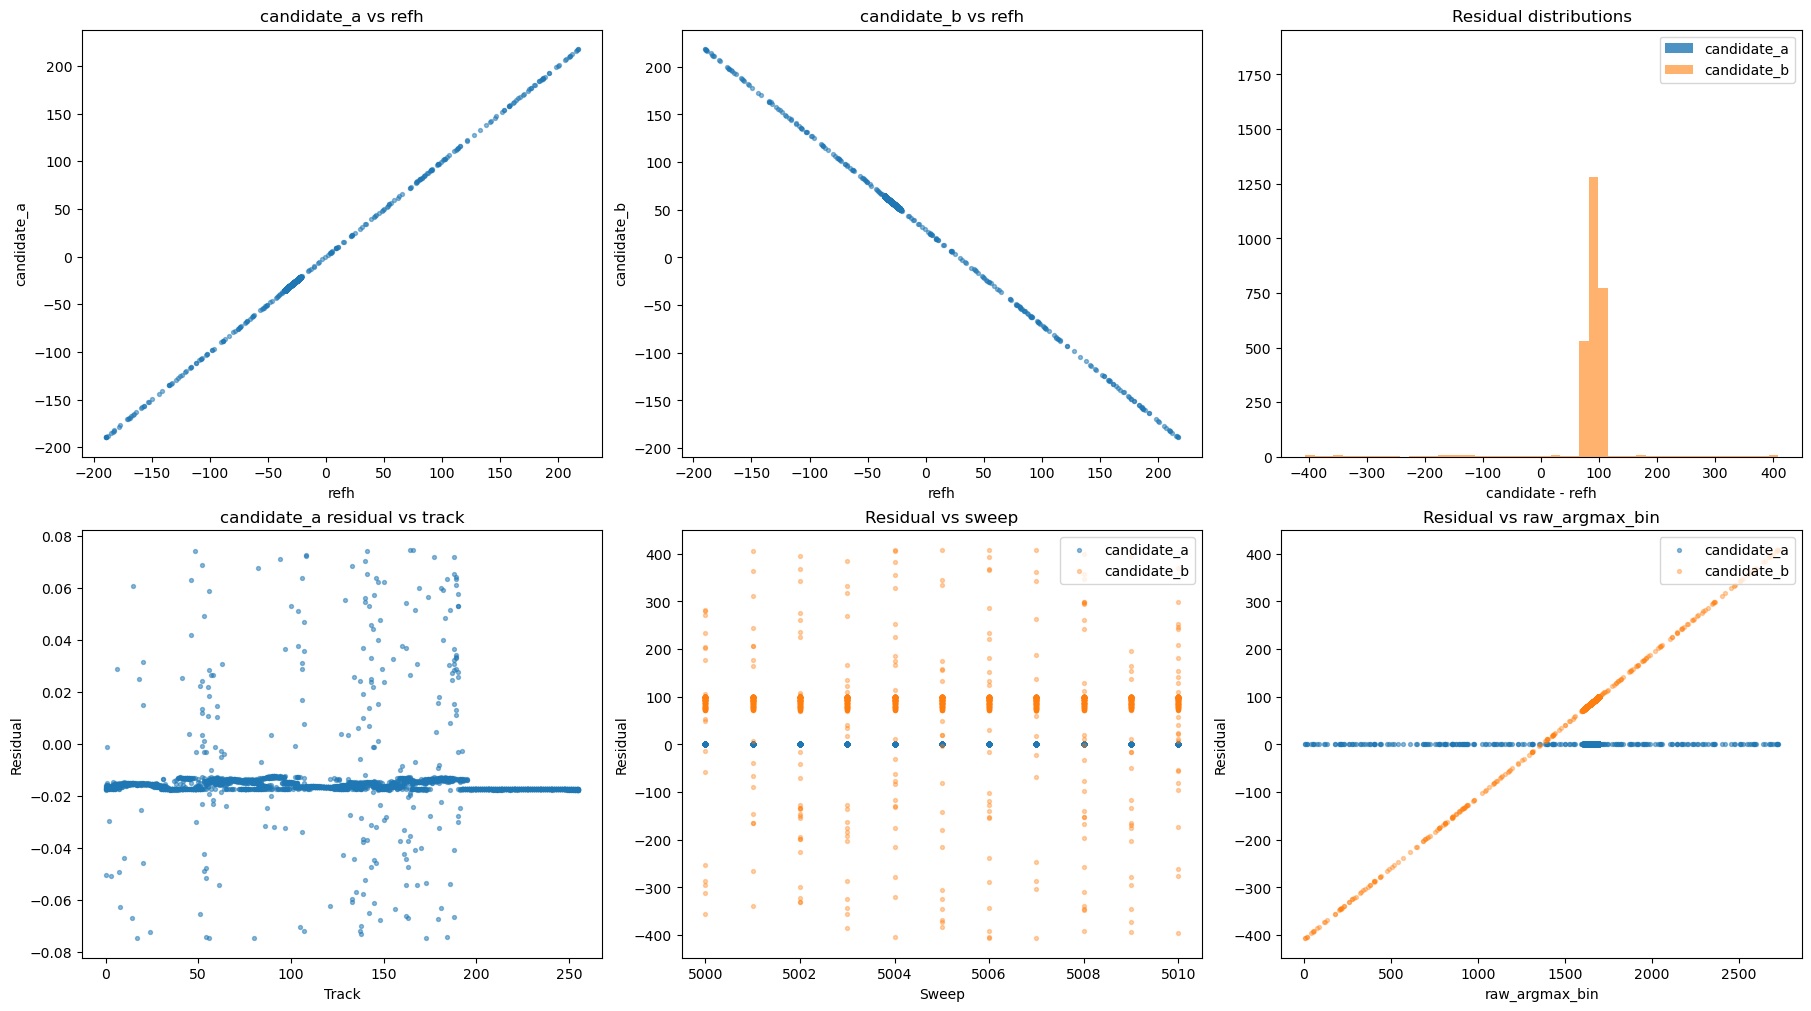

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

axes[0, 0].scatter(mapping_df["refh"], mapping_df["candidate_a"], s=8, alpha=0.5)
axes[0, 0].set_title("candidate_a vs refh")
axes[0, 0].set_xlabel("refh")
axes[0, 0].set_ylabel("candidate_a")

axes[0, 1].scatter(mapping_df["refh"], mapping_df["candidate_b"], s=8, alpha=0.5)
axes[0, 1].set_title("candidate_b vs refh")
axes[0, 1].set_xlabel("refh")
axes[0, 1].set_ylabel("candidate_b")

axes[0, 2].hist(mapping_df["resid_a"].dropna(), bins=50, color="tab:blue", alpha=0.8, label="candidate_a")
axes[0, 2].hist(mapping_df["resid_b"].dropna(), bins=50, color="tab:orange", alpha=0.6, label="candidate_b")
axes[0, 2].set_title("Residual distributions")
axes[0, 2].set_xlabel("candidate - refh")
axes[0, 2].legend(loc="upper right")

axes[1, 0].scatter(mapping_df["track_num"], mapping_df["resid_a"], s=8, alpha=0.5)
axes[1, 0].set_title("candidate_a residual vs track")
axes[1, 0].set_xlabel("Track")
axes[1, 0].set_ylabel("Residual")

axes[1, 1].scatter(mapping_df["sweep_num"], mapping_df["resid_a"], s=8, alpha=0.5, label="candidate_a")
axes[1, 1].scatter(mapping_df["sweep_num"], mapping_df["resid_b"], s=8, alpha=0.35, label="candidate_b")
axes[1, 1].set_title("Residual vs sweep")
axes[1, 1].set_xlabel("Sweep")
axes[1, 1].set_ylabel("Residual")
axes[1, 1].legend(loc="upper right")

axes[1, 2].scatter(mapping_df["raw_argmax_bin"], mapping_df["resid_a"], s=8, alpha=0.5, label="candidate_a")
axes[1, 2].scatter(mapping_df["raw_argmax_bin"], mapping_df["resid_b"], s=8, alpha=0.35, label="candidate_b")
axes[1, 2].set_title("Residual vs raw_argmax_bin")
axes[1, 2].set_xlabel("raw_argmax_bin")
axes[1, 2].set_ylabel("Residual")
axes[1, 2].legend(loc="upper right")

plt.show()

In [5]:
a_nmad = float(summary_table.loc["nmad", "candidate_a"])
b_nmad = float(summary_table.loc["nmad", "candidate_b"])
a_p95 = float(summary_table.loc["p95_abs", "candidate_a"])
b_p95 = float(summary_table.loc["p95_abs", "candidate_b"])

if min(a_nmad, b_nmad) > 2.0 or min(a_p95, b_p95) > 5.0:
    print("No reliable bin-to-height mapping is supported by this simple rwstart/rwstop linear hypothesis.")
elif a_nmad <= b_nmad:
    print("This supports a tentative relative bin-height mapping hypothesis, but does not georeference secondary components in lon/lat.")
    print("Better-performing candidate:", "candidate_a")
else:
    print("This supports a tentative relative bin-height mapping hypothesis, but does not georeference secondary components in lon/lat.")
    print("Better-performing candidate:", "candidate_b")

This supports a tentative relative bin-height mapping hypothesis, but does not georeference secondary components in lon/lat.
Better-performing candidate: candidate_a
